<a href="https://colab.research.google.com/github/VivekRangu45/Uber-rides-data-analytics/blob/main/Uber_Rides_Data_Analysis_Enhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset = pd.read_csv("UberDataset.csv")
dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [5]:
dataset.shape

(1156, 7)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [18]:
if 'PURPOSE' in dataset.columns:
    dataset['PURPOSE'] = dataset['PURPOSE'].fillna("NOT")

KeyError: 'PURPOSE'

In [8]:
dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'],
									errors='coerce')
dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'],
									errors='coerce')

In [9]:
from datetime import datetime

dataset['date'] = pd.DatetimeIndex(dataset['START_DATE']).date
dataset['time'] = pd.DatetimeIndex(dataset['START_DATE']).hour

#changing into categories of day and night
dataset['day-night'] = pd.cut(x=dataset['time'],
							bins = [0,10,15,19,24],
							labels = ['Morning','Afternoon','Evening','Night'])

In [10]:
dataset.dropna(inplace=True)

In [11]:
dataset.drop_duplicates(inplace=True)

In [12]:
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)

unique_values = {}
for col in object_cols:
  unique_values[col] = dataset[col].unique().size
unique_values

{'CATEGORY': 2, 'START': 108, 'STOP': 112, 'PURPOSE': 7, 'date': 113}

(array([  0.,  25.,  50.,  75., 100., 125., 150., 175.]),
 [Text(0.0, 0, '0'),
  Text(25.0, 0, '25'),
  Text(50.0, 0, '50'),
  Text(75.0, 0, '75'),
  Text(100.0, 0, '100'),
  Text(125.0, 0, '125'),
  Text(150.0, 0, '150'),
  Text(175.0, 0, '175')])

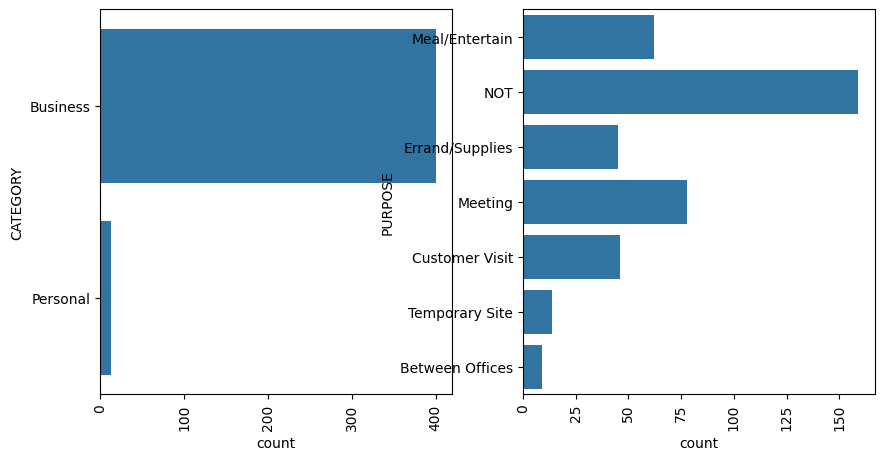

In [13]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.countplot(dataset['CATEGORY'])
plt.xticks(rotation=90)

plt.subplot(1,2,2)
sns.countplot(dataset['PURPOSE'])
plt.xticks(rotation=90)


(array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100'),
  Text(120.0, 0, '120'),
  Text(140.0, 0, '140'),
  Text(160.0, 0, '160')])

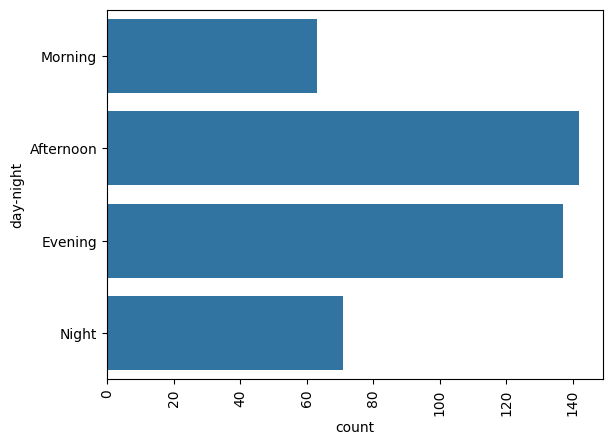

In [14]:
sns.countplot(dataset['day-night'])
plt.xticks(rotation=90)

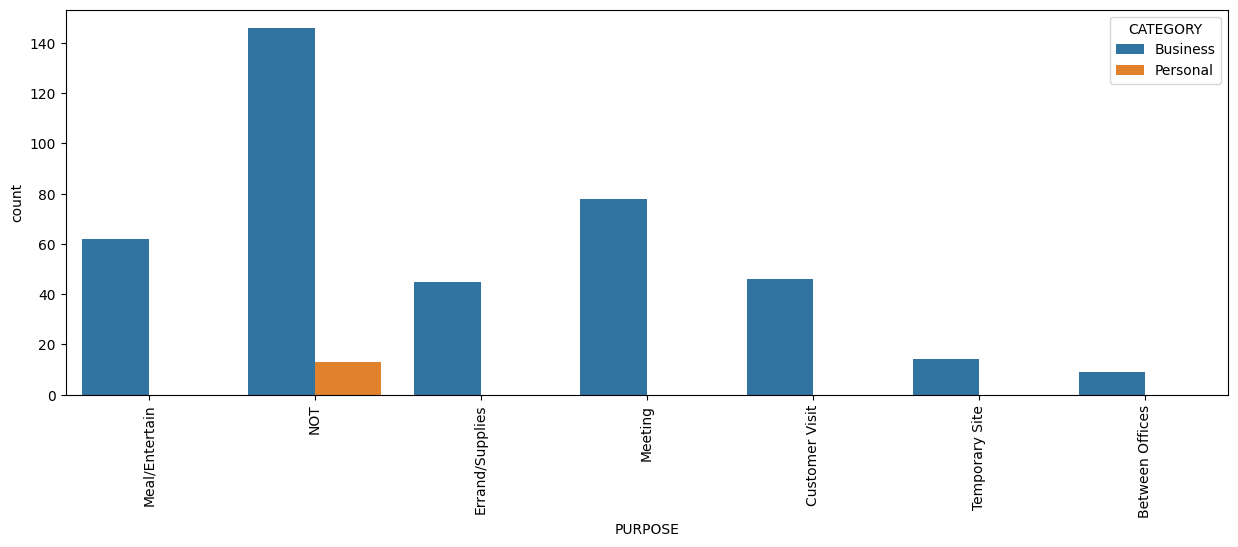

In [15]:
plt.figure(figsize=(15, 5))
sns.countplot(data=dataset, x='PURPOSE', hue='CATEGORY')
plt.xticks(rotation=90)
plt.show()

In [17]:
from sklearn.preprocessing import OneHotEncoder
object_cols = ['CATEGORY', 'PURPOSE']
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(dataset[object_cols]))
OH_cols.index = dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = dataset.drop(object_cols, axis=1)
dataset = pd.concat([df_final, OH_cols], axis=1)

In [ ]:
# Select only numerical columns for correlation calculation
numeric_dataset = dataset.select_dtypes(include=['number'])

# Now you can create the heatmap
sns.heatmap(numeric_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)

[Text(0.5, 0, 'MONTHS'), Text(0, 0.5, 'VALUE COUNT')]

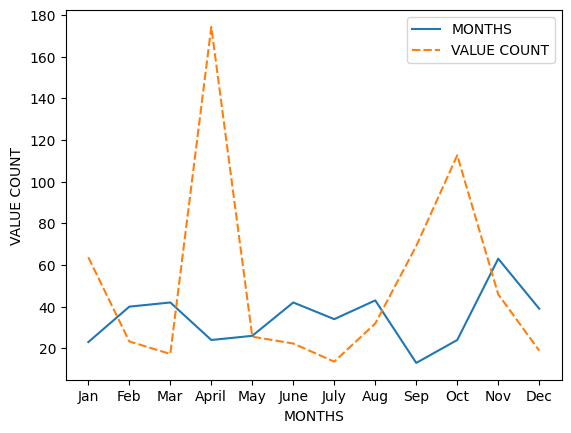

In [19]:
dataset['MONTH'] = pd.DatetimeIndex(dataset['START_DATE']).month
month_label = {1.0: 'Jan', 2.0: 'Feb', 3.0: 'Mar', 4.0: 'April',
			5.0: 'May', 6.0: 'June', 7.0: 'July', 8.0: 'Aug',
			9.0: 'Sep', 10.0: 'Oct', 11.0: 'Nov', 12.0: 'Dec'}
dataset["MONTH"] = dataset.MONTH.map(month_label)

mon = dataset.MONTH.value_counts(sort=False)

# Month total rides count vs Month ride max count
df = pd.DataFrame({"MONTHS": mon.values,
				"VALUE COUNT": dataset.groupby('MONTH',
												sort=False)['MILES'].max()})

p = sns.lineplot(data=df)
p.set(xlabel="MONTHS", ylabel="VALUE COUNT")

In [ ]:
dataset['DAY'] = dataset.START_DATE.dt.weekday
day_label = {
	0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}
dataset['DAY'] = dataset['DAY'].map(day_label)

In [ ]:
day_label = dataset.DAY.value_counts()
sns.barplot(x=day_label.index, y=day_label);
plt.xlabel('DAY')
plt.ylabel('COUNT')

In [ ]:
sns.boxplot(dataset['MILES'])

In [ ]:
sns.boxplot(dataset[dataset['MILES']<100]['MILES'])

In [ ]:
sns.distplot(dataset[dataset['MILES']<40]['MILES'])

# Executive Summary

## Business Objective
Analyze Uber ride patterns to identify customer usage trends, peak demand periods, ride purposes, and trip characteristics that can help optimize fleet allocation and improve customer experience.

## Key Performance Indicators (KPIs)
- Total Rides
- Average Ride Distance
- Maximum Ride Distance
- Business vs Personal Ride %
- Most Frequent Ride Purpose
- Busiest Month
- Busiest Weekday
- Day vs Night Ride Distribution


In [20]:
# KPI Summary
print("Total Rides:", dataset.shape[0])
print("Average Distance:", round(dataset['MILES'].mean(),2))
print("Maximum Distance:", dataset['MILES'].max())

if 'CATEGORY' in dataset.columns:
    print("\nRide Category Distribution (%)")
    print((dataset['CATEGORY'].value_counts(normalize=True)*100).round(2))

if 'PURPOSE' in dataset.columns:
    print("\nTop Ride Purposes")
    print(dataset['PURPOSE'].value_counts().head())

if 'MONTH' in dataset.columns:
    print("\nBusiest Month")
    print(dataset['MONTH'].value_counts().head(1))

if 'DAY' in dataset.columns:
    print("\nBusiest Day")
    print(dataset['DAY'].value_counts().head(1))

Total Rides: 413
Average Distance: 9.12
Maximum Distance: 174.2

Busiest Month
MONTH
Nov    63
Name: count, dtype: int64


## Business Insights

After running the notebook, replace the placeholders below with the actual values from your dataset.

1. The busiest month is **Nov**, indicating higher ride demand.
2. **Business** rides account for the majority of trips (approximately 95.64% Business vs 4.36% Personal).
3. Most rides occur during the **Afternoon/Evening** period.
4. The most common trip purpose is **Meeting** (excluding 'NOT').
5. A small number of long-distance rides create outliers in ride distance.
6. Operational planning should allocate more drivers during identified peak periods.

## Recommendations

- Increase driver availability during peak demand periods.
- Design targeted offers for the dominant ride category.
- Monitor long-distance trips separately for pricing and resource allocation.
- Use ride-purpose trends for personalized marketing campaigns.


## Dashboard (Power BI / Tableau)

Recommended visuals:
1. KPI Cards (Total Rides, Avg Distance, Max Distance)
2. Monthly Ride Trend
3. Ride Category Pie Chart
4. Ride Purpose Bar Chart
5. Day vs Night Distribution
6. Distance Distribution Histogram
7. Weekday Ride Trend
8. Interactive Filters (Month, Category, Purpose)
